In [1]:
!pip3 install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
# Import userdata to access Colab secrets
from google.colab import userdata

# Retrieve your API key from Colab Secrets
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

# Verify that the API key was loaded (optional, remove for production)
print(f"API Key loaded successfully: {ROBOFLOW_API_KEY is not None}")

API Key loaded successfully: True


In [3]:
from roboflow import Roboflow
import os

# rf = Roboflow(api_key="Sl3NeQEJVwz0j0lhNlOV")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("humilityhub").project("plate_number_detection-3nzgb")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plate_Number_Detection-1 in yolov8:: 100%|██████████| 3599/3599 [00:01<00:00, 3146.77it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/Plate_Number_Detection-1/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Plate_Number_Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3f8b8b8d10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val(
    data="/content/Plate_Number_Detection-1/data.yaml",
    split="test"
)

print("mAP50-95:", metrics.box.map)
print("mAP50:", metrics.box.map50)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 858.6±318.6 MB/s, size: 48.2 KB)
val: Scanning /content/Plate_Number_Detection-1/test/labels... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 1.9Kit/s 0.1s
val: New cache created: /content/Plate_Number_Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.0it/s 2.4s
                   all        100        100      0.999          1      0.995      0.851
Speed: 5.2ms preprocess, 6.1ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val2
mAP50-95: 0.8511807287116152
mAP50: 0.995
Precision: 0.9990658814350393
Recall: 1.0


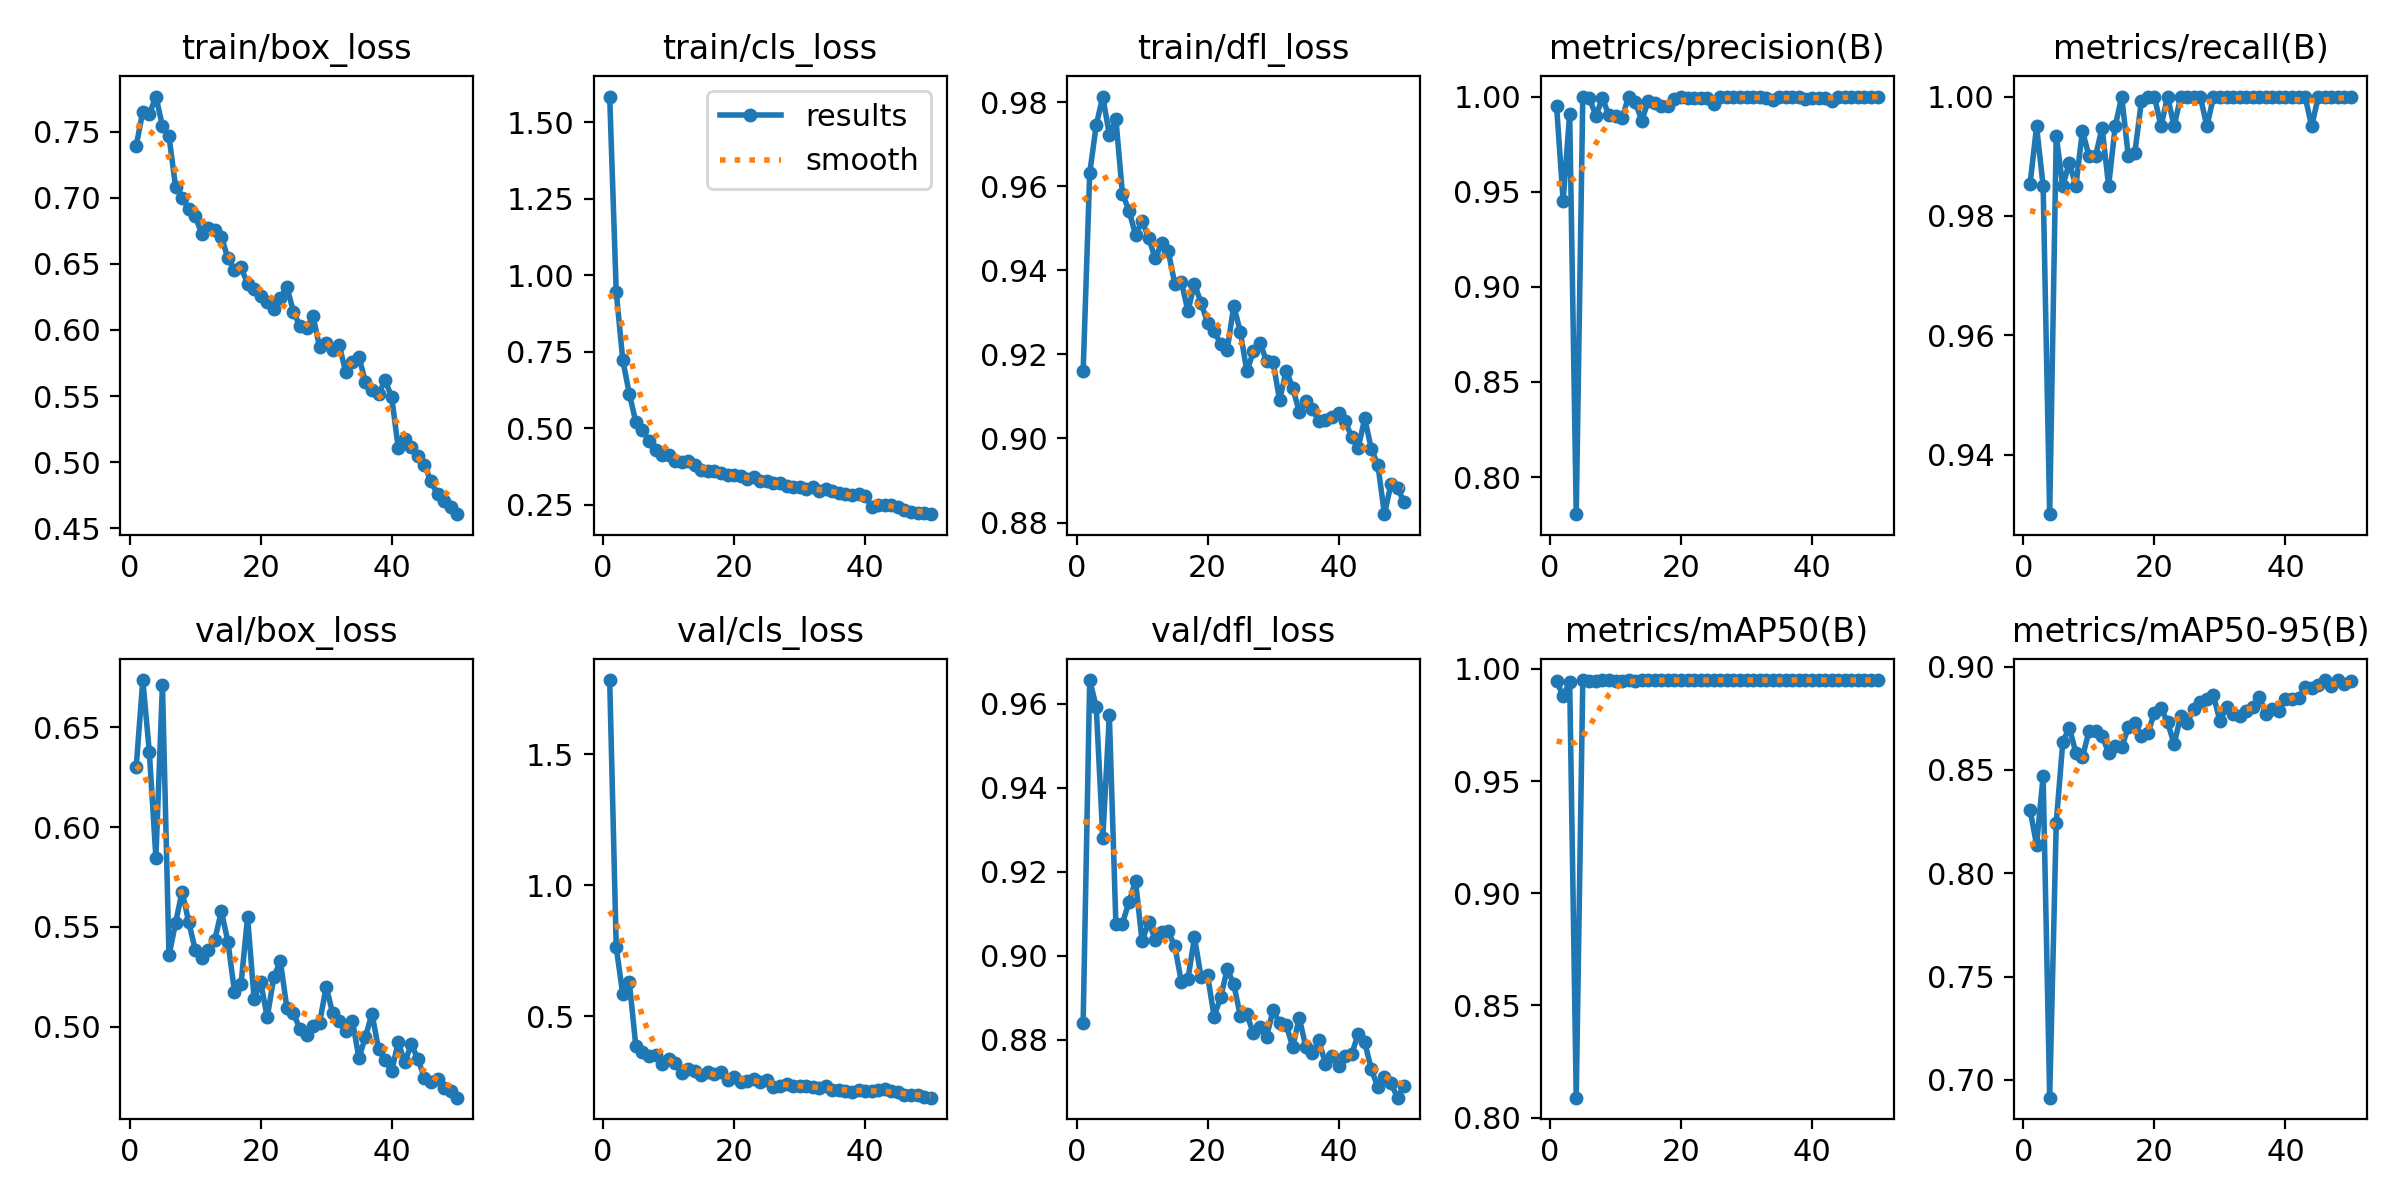

In [7]:
from IPython.display import Image

Image("/content/runs/detect/train/results.png")

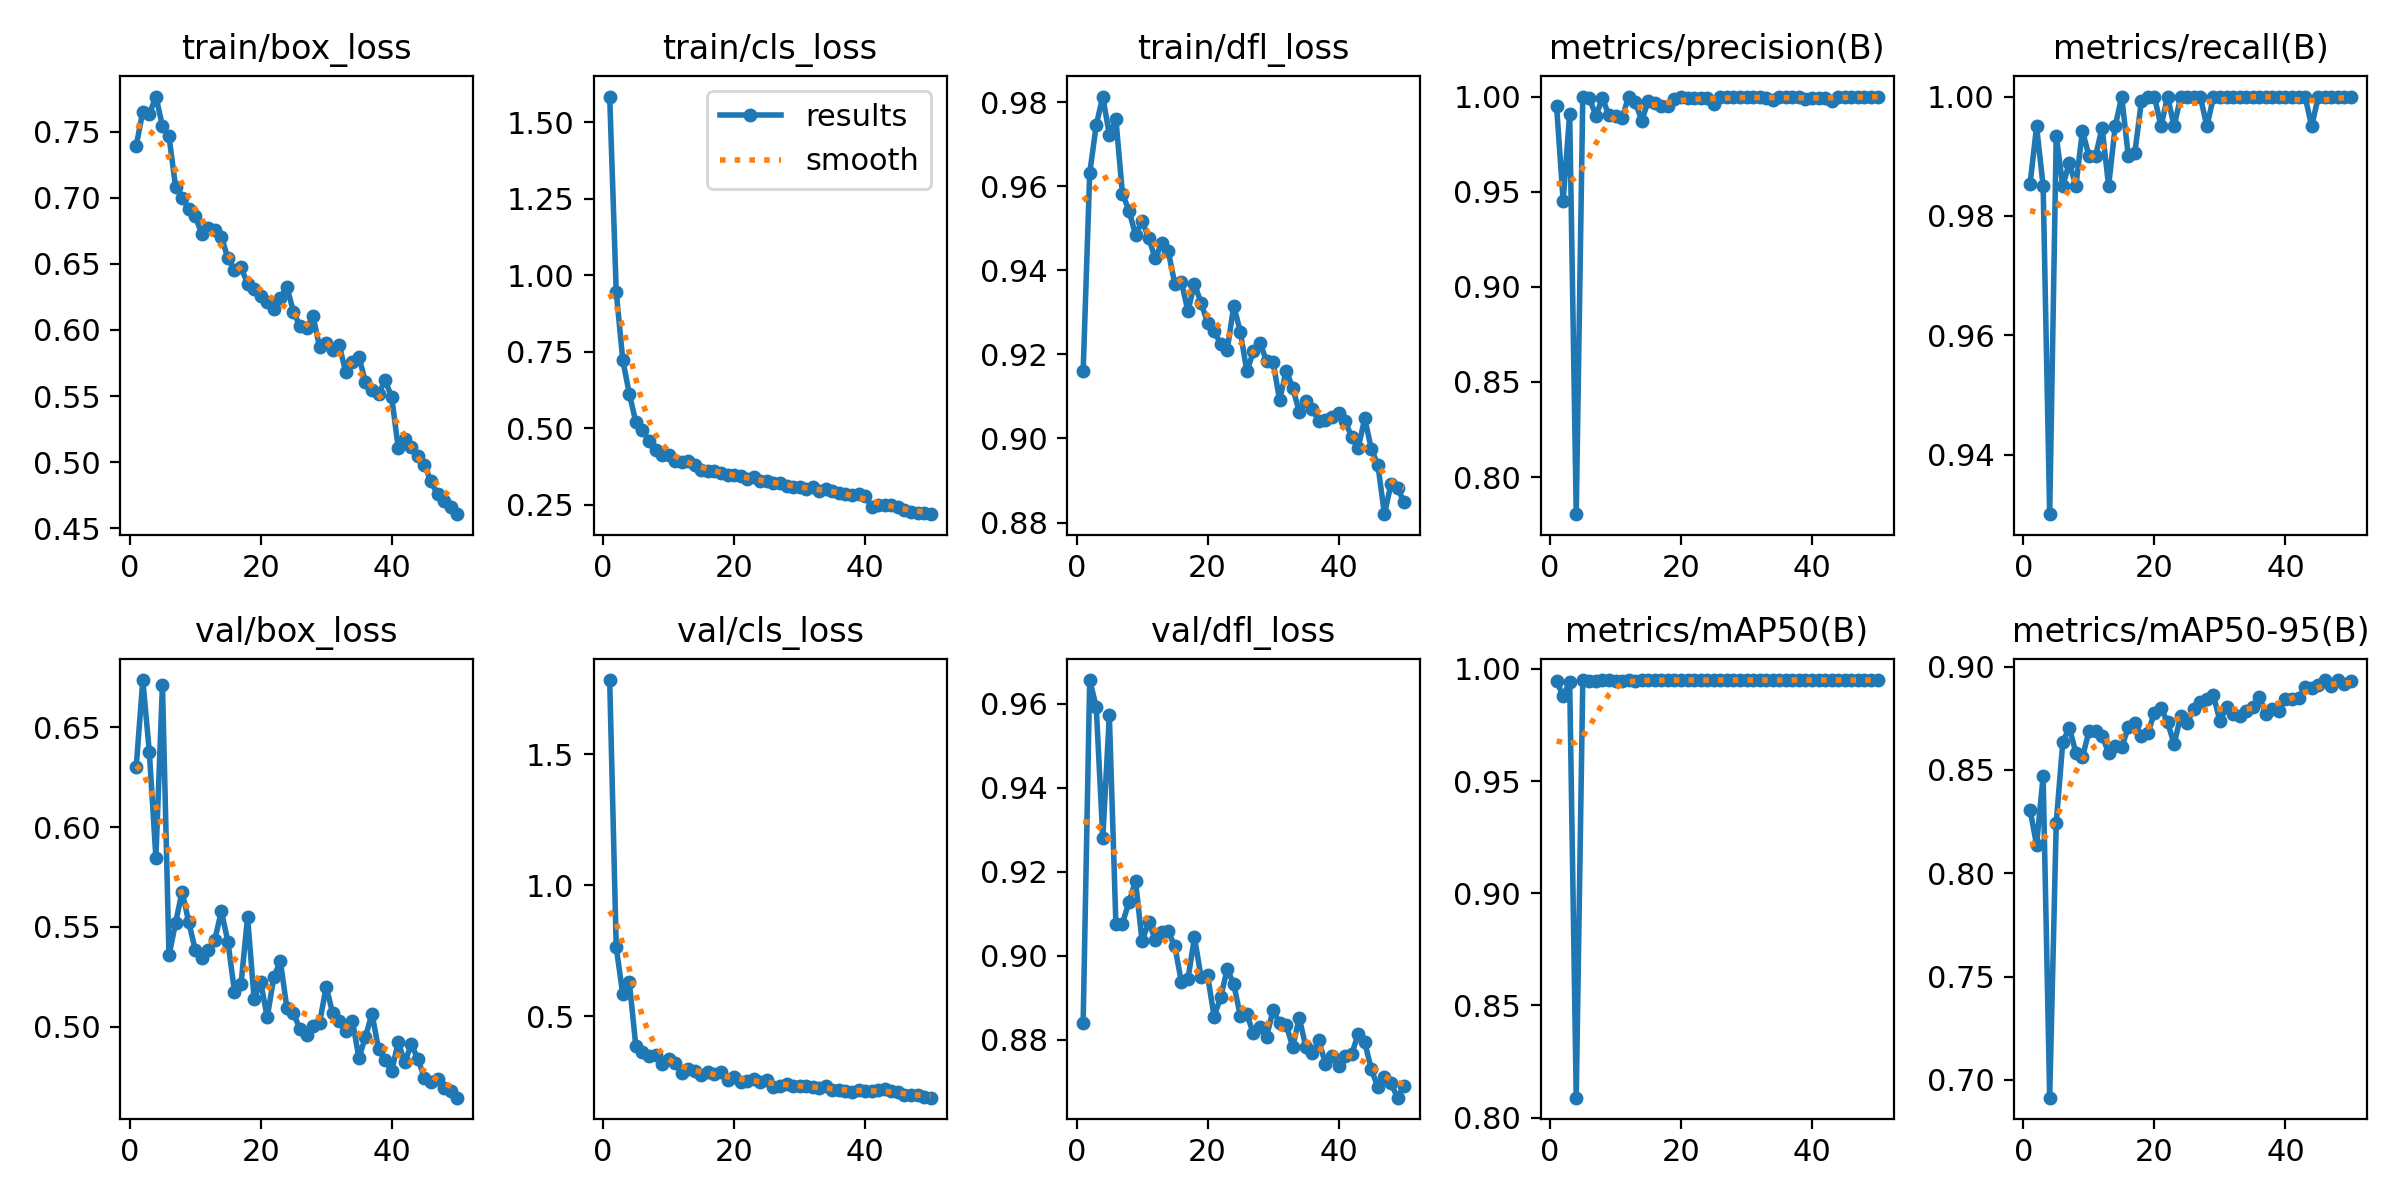

In [9]:
Image("/content/runs/detect/train/results.png")

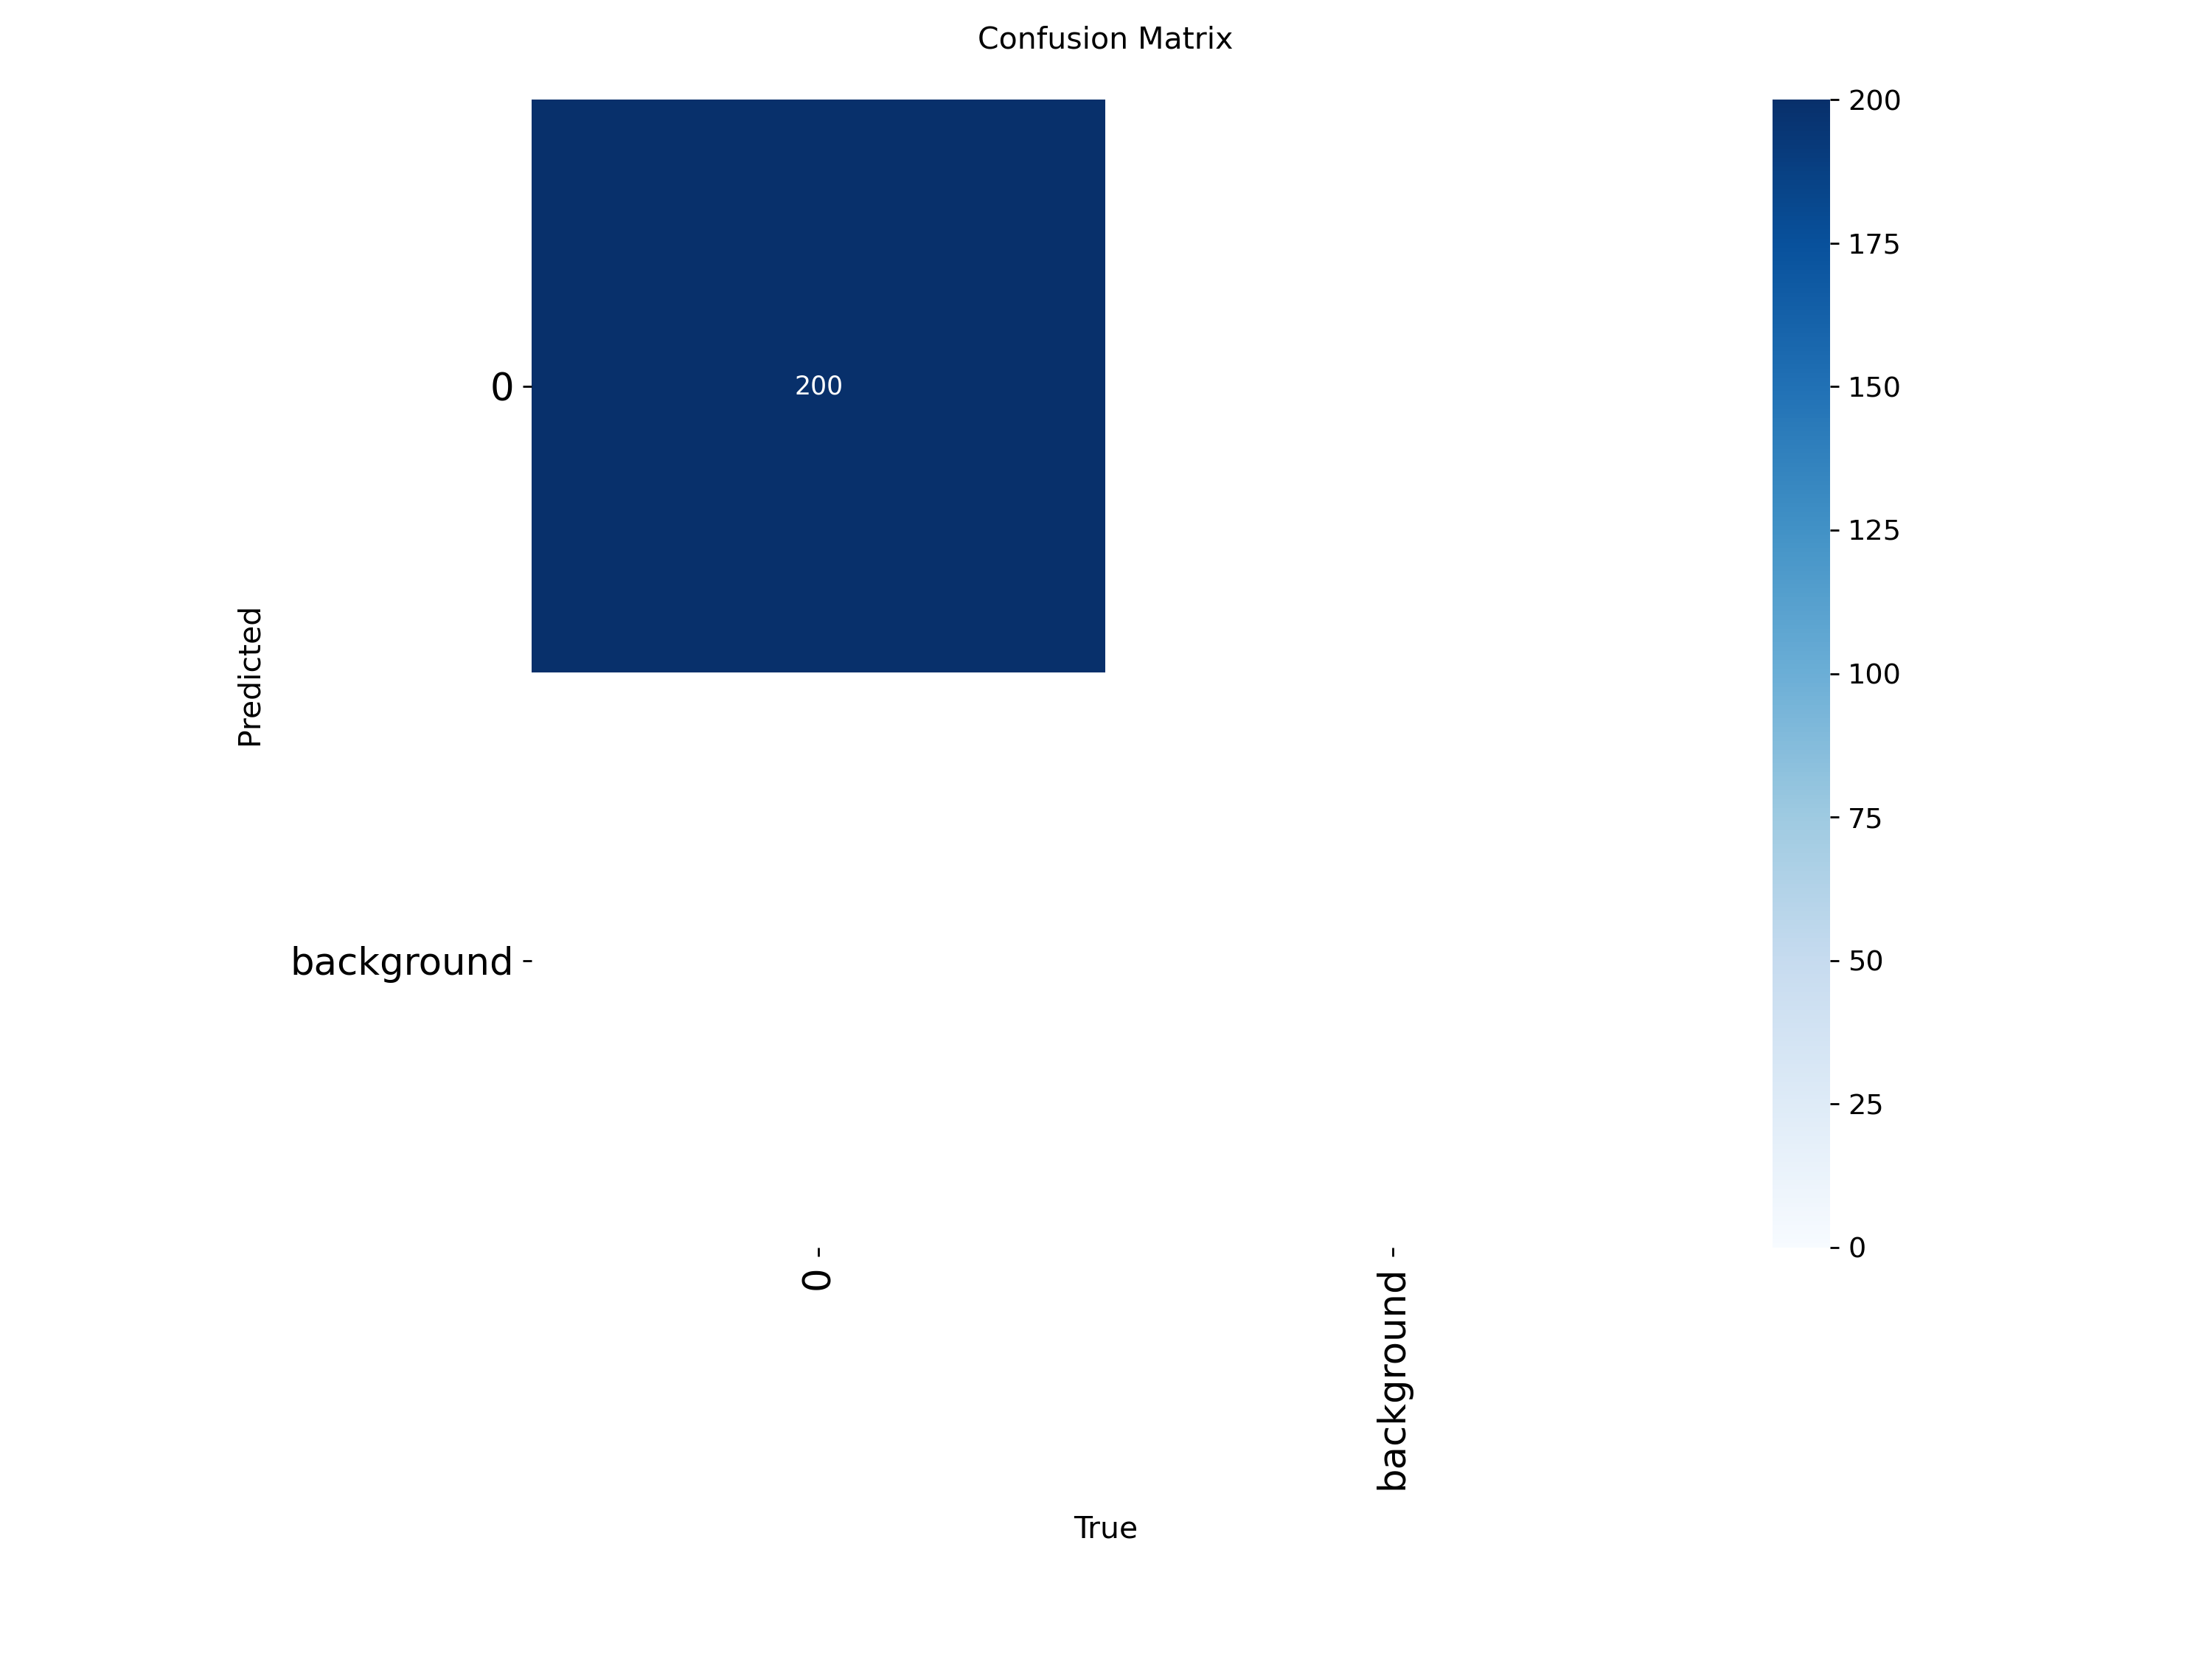

In [10]:
Image("/content/runs/detect/train/confusion_matrix.png")

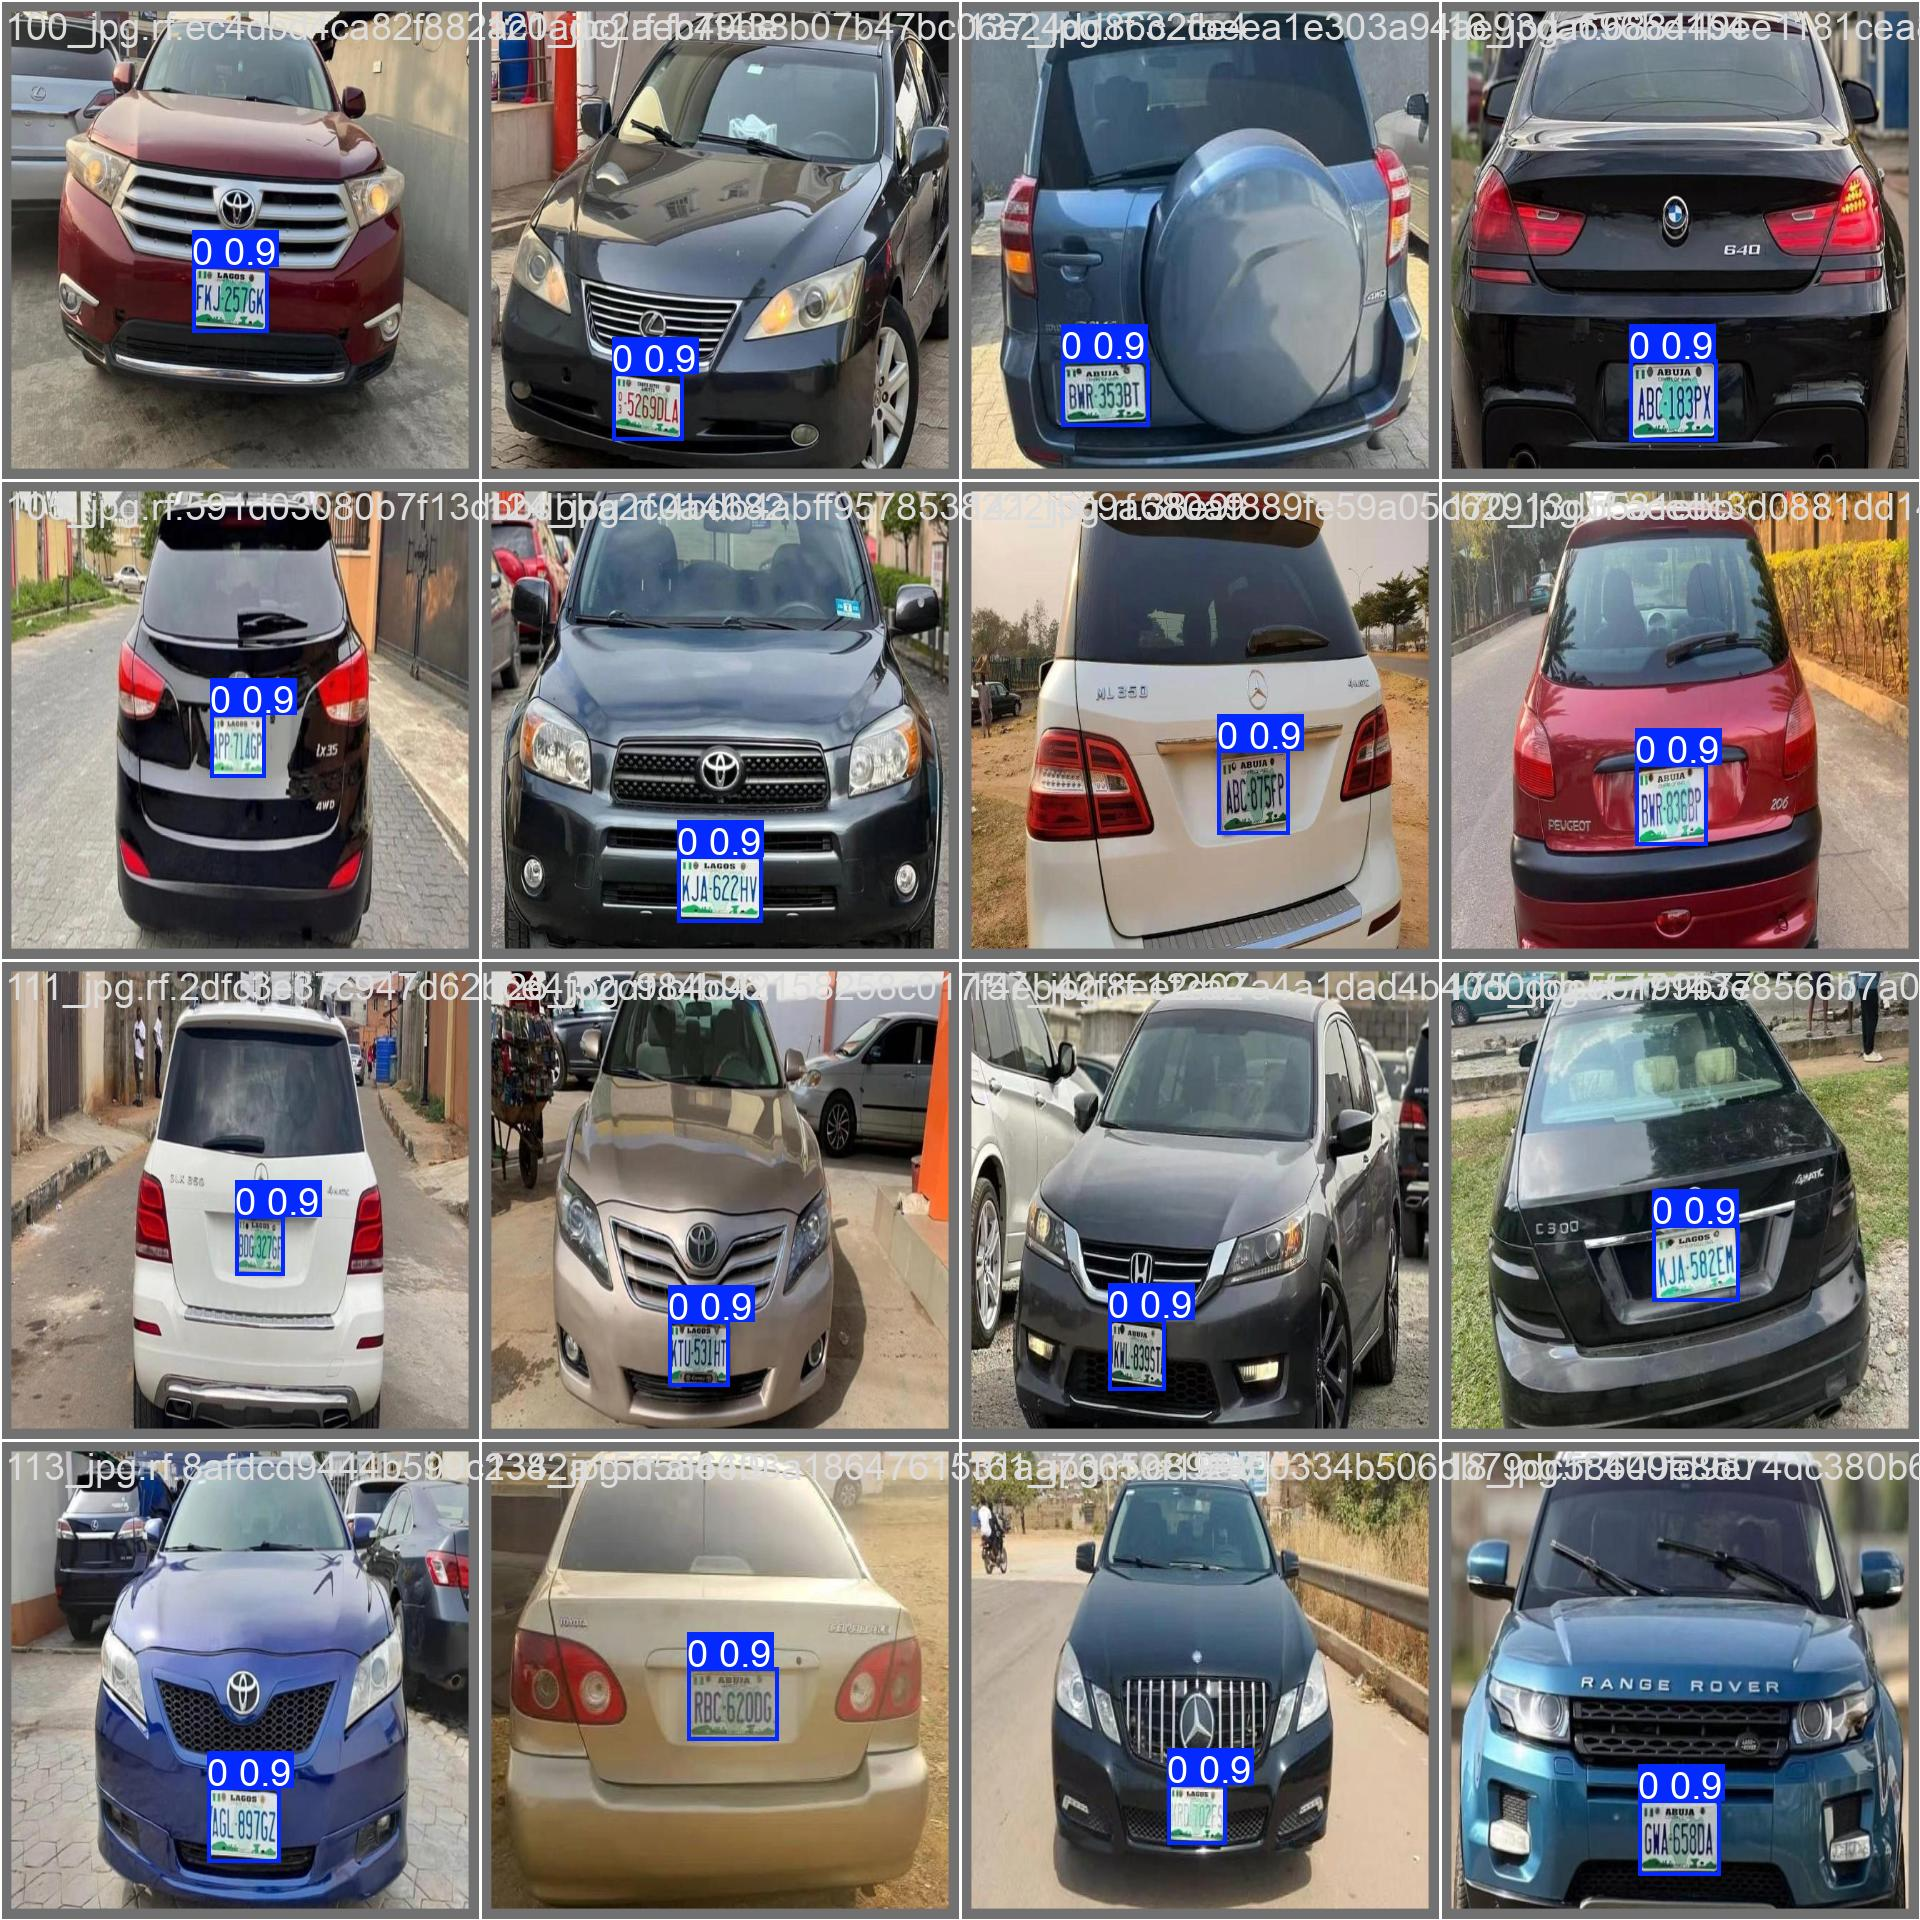

In [11]:
Image("/content/runs/detect/train/val_batch0_pred.jpg")

In [13]:
model.predict(
    source="/content/Plate_Number_Detection-1/test/images",
    save=True
)


image 1/100 /content/Plate_Number_Detection-1/test/images/103_jpg.rf.29e7de05803d4791fb0e94f8427d2e2a.jpg: 640x640 1 0, 9.0ms
image 2/100 /content/Plate_Number_Detection-1/test/images/118_jpg.rf.6c983144d61fa94f258d2e5189e81ebd.jpg: 640x640 1 0, 7.2ms
image 3/100 /content/Plate_Number_Detection-1/test/images/119_jpg.rf.3b129b446789d3e273988794b186a1e5.jpg: 640x640 1 0, 7.2ms
image 4/100 /content/Plate_Number_Detection-1/test/images/128_jpg.rf.1073a209c353b246095d85ed0643a5de.jpg: 640x640 1 0, 10.2ms
image 5/100 /content/Plate_Number_Detection-1/test/images/145_jpg.rf.b6b267ece6f4b4f08d038e96caf8553f.jpg: 640x640 1 0, 7.2ms
image 6/100 /content/Plate_Number_Detection-1/test/images/154_jpg.rf.400f41d0c5dbdb861a5112d46bd81120.jpg: 640x640 1 0, 7.2ms
image 7/100 /content/Plate_Number_Detection-1/test/images/155_jpg.rf.136f165533c1b85222e98b247a27f29a.jpg: 640x640 1 0, 7.2ms
image 8/100 /content/Plate_Number_Detection-1/test/images/167_jpg.rf.6c96c6f80b7f13ef1f8df6d08f377108.jpg: 640x640 1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0'}
 obb: None
 orig_img: array([[[ 49,  64,  83],
         [ 49,  64,  83],
         [ 46,  63,  82],
         ...,
         [254, 255, 253],
         [254, 255, 253],
         [254, 255, 253]],
 
        [[ 48,  63,  82],
         [ 48,  63,  82],
         [ 45,  62,  81],
         ...,
         [251, 252, 250],
         [251, 252, 250],
         [251, 252, 250]],
 
        [[ 46,  61,  80],
         [ 46,  61,  80],
         [ 43,  60,  79],
         ...,
         [251, 252, 250],
         [251, 252, 250],
         [251, 252, 250]],
 
        ...,
 
        [[113, 136, 168],
         [121, 144, 176],
         [112, 135, 167],
         ...,
         [108, 132, 168],
         [111, 135, 171],
         [115, 139, 175]],
 
        [[108, 131, 163],
         [121, 144, 176],
         [110, 133, 165],
         ...,
         [107, 131, 167

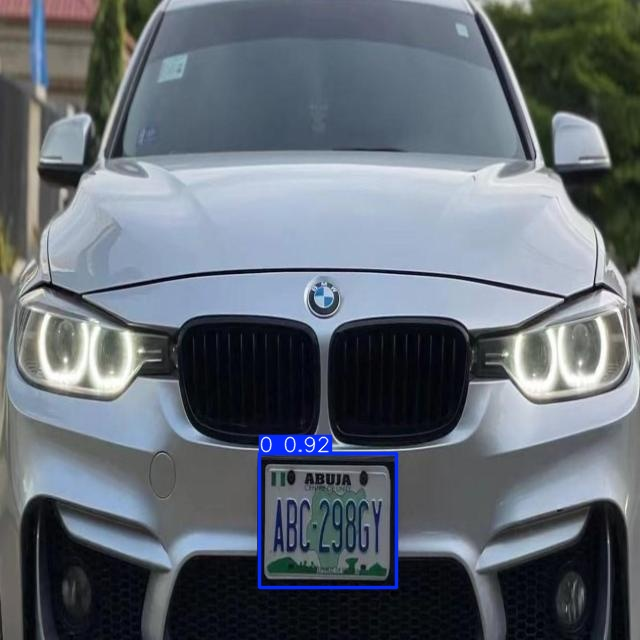

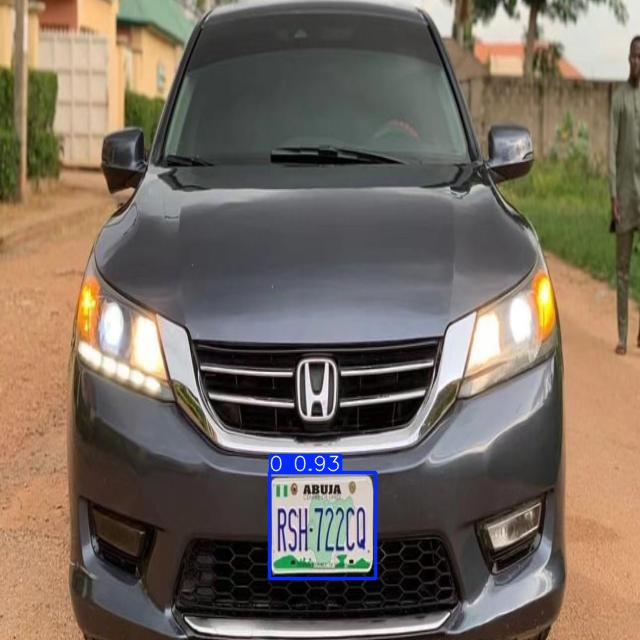

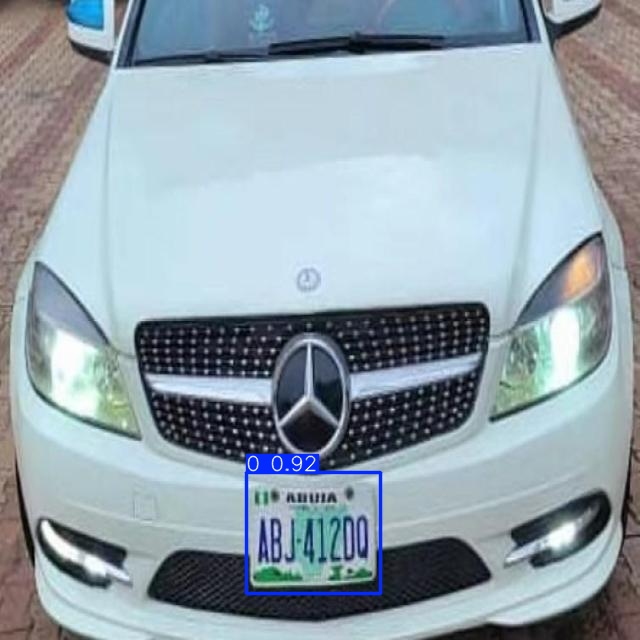

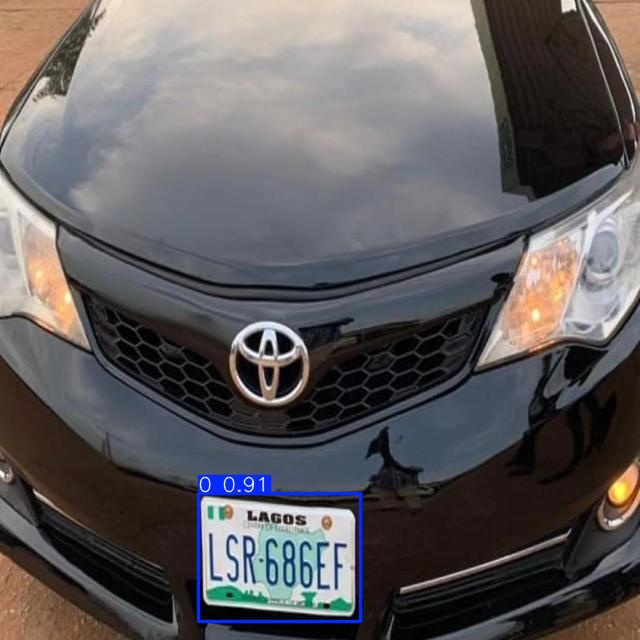

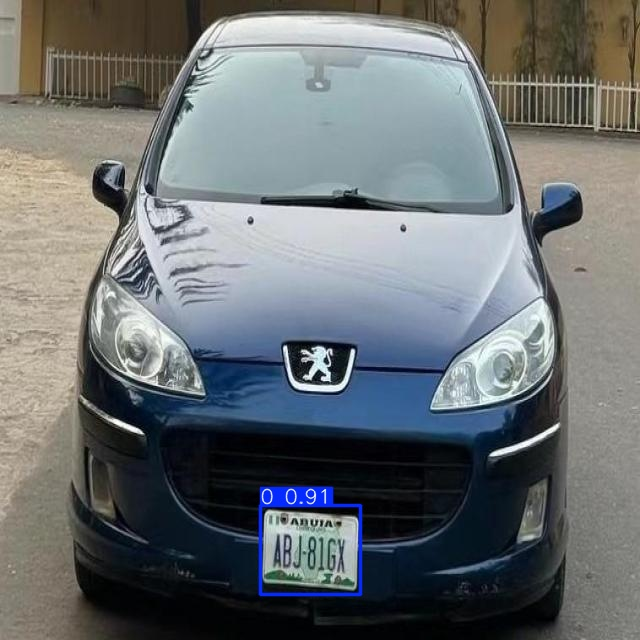

In [14]:
import os
from IPython.display import Image, display

test_dir = "/content/runs/detect/predict"

for img in os.listdir(test_dir)[:5]:
    display(Image(os.path.join(test_dir, img)))

# Using validation and test result to Check for overfitting

In [16]:
val_metrics = model.val(data="/content/Plate_Number_Detection-1/data.yaml", split="val")
test_metrics = model.val(data="/content/Plate_Number_Detection-1/data.yaml", split="test")

print("VAL mAP50:", val_metrics.box.map50)
print("TEST mAP50:", test_metrics.box.map50)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1738.2±612.4 MB/s, size: 51.1 KB)
val: Scanning /content/Plate_Number_Detection-1/valid/labels.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 64.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.9it/s 4.5s
                   all        200        200          1          1      0.995      0.894
Speed: 4.2ms preprocess, 4.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val4
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.7±489.3 MB/s, size: 56.4 KB)
val: Scanning /content/Plate_Number_Detection-1/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 30.0Mit/s 0.0s
                 Class     Im

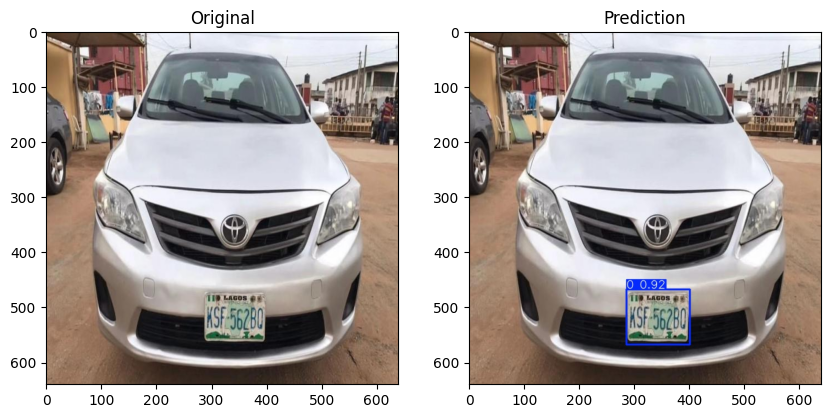

In [18]:
# original vs predicted
import cv2
import matplotlib.pyplot as plt

# Use an existing image from the test set and its corresponding prediction
original_image_path = "/content/Plate_Number_Detection-1/test/images/103_jpg.rf.29e7de05803d4791fb0e94f8427d2e2a.jpg"
predicted_image_path = "/content/runs/detect/predict/103_jpg.rf.29e7de05803d4791fb0e94f8427d2e2a.jpg"

img = cv2.imread(original_image_path)
pred = cv2.imread(predicted_image_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(cv2.cvtColor(pred, cv2.COLOR_BGR2RGB))

plt.show()